**24BAD130 Vishal S ML Lab Exp No -09 Implementation of Ensemble Techniques **

**SCENARIO 1 – (Bagging)**

Problem Statement:
Predict whether a patient has diabetes.
Dataset:
Diabetes Dataset
Target Variable:
Outcome (0 = No Diabetes, 1 = Diabetes)
Input Features:
Glucose, BMI, Age, Blood Pressure, etc.

IN-LAB TASKS
•	Load dataset
•	Train Decision Tree
•	Apply BaggingClassifier
•	Compare accuracy
Visualization
•	Accuracy comparison bar graph
•	Confusion matrix


In [1]:
#Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
#Load Dataset
data = pd.read_csv("diabetes_bagging.csv")

In [3]:
data.head()

,Glucose,BMI,Age,BloodPressure,Insulin,Outcome
0,182,21.1,45,99,100,1
1,131,35.6,67,92,199,1
2,172,19.6,68,68,234,1
3,94,39.7,21,102,83,0
4,186,35.0,20,113,61,1


In [4]:
#Split Features & Target
X = data.drop("Outcome", axis=1)
y = data["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [5]:
#Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 1.0


In [6]:
#Apply Bagging Classifier
bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42)

bag_model.fit(X_train, y_train)

y_pred_bag = bag_model.predict(X_test)

bag_accuracy = accuracy_score(y_test, y_pred_bag)
print("Bagging Accuracy:", bag_accuracy)

Bagging Accuracy: 1.0


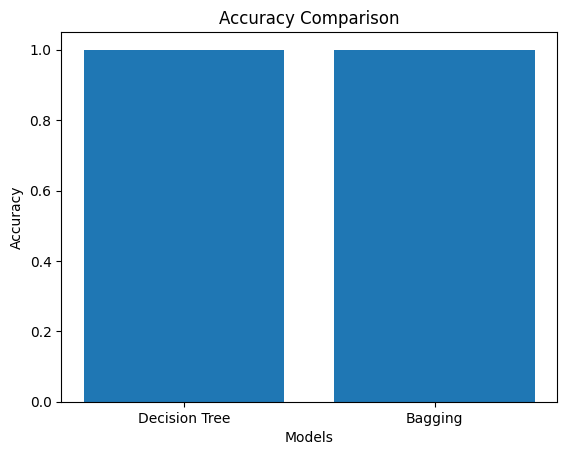

In [7]:
#Accuracy Comparison (Bar Graph)
models = ["Decision Tree", "Bagging"]
accuracies = [dt_accuracy, bag_accuracy]

plt.figure()
plt.bar(models, accuracies)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.show()

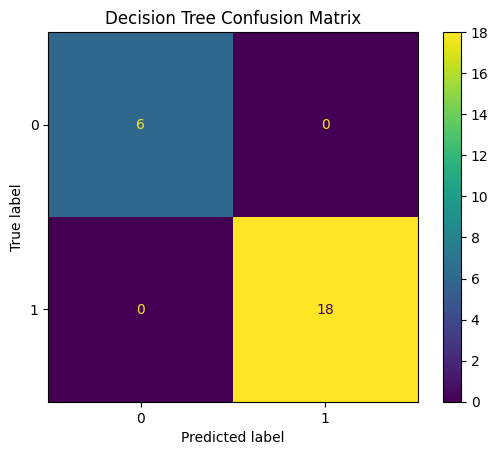

In [8]:
#Confusion Matrix
#For Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

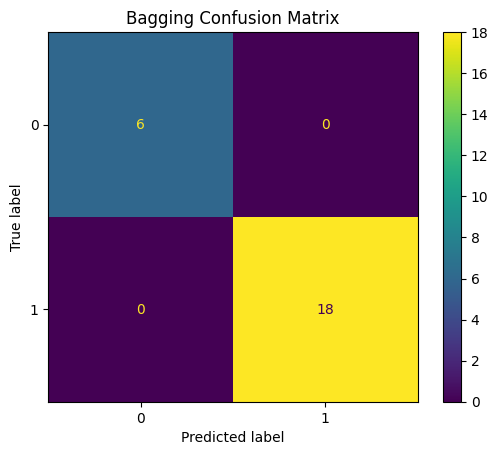

In [9]:
#For Bagging
cm_bag = confusion_matrix(y_test, y_pred_bag)
disp_bag = ConfusionMatrixDisplay(confusion_matrix=cm_bag)
disp_bag.plot()
plt.title("Bagging Confusion Matrix")
plt.show()

**SCENARIO 2 – (Boosting-AdaBoost, Gradient Boosting)**

Problem Statement:
Predict whether a customer will churn.
Dataset:
Telco Customer Churn Dataset
Target Variable:
Churn (Yes/No)
Input Features:
Tenure, Monthly Charges, Contract Type

IN-LAB TASKS
•	Train AdaBoost
•	Train Gradient Boosting
•	Compare performance
Visualization
•	ROC Curve
•	Feature Importance plot



In [12]:
#Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

In [13]:
#Load Dataset
data = pd.read_csv("churn_boosting.csv")

In [14]:
data.head()

,Tenure,MonthlyCharges,ContractType,InternetService,Churn
0,65,105.22,Two year,NaN,0
1,17,75.19,Month-to-month,NaN,0
2,71,76.09,Two year,Fiber optic,0
3,45,107.67,Two year,Fiber optic,0
4,4,60.35,Two year,NaN,0


In [15]:
#Preprocessing
# Convert target variable (Yes/No → 1/0)
le = LabelEncoder()
data['Churn'] = le.fit_transform(data['Churn'])

# Convert categorical columns (like Contract Type)
data = pd.get_dummies(data, drop_first=True)

# Split features and target
X = data.drop("Churn", axis=1)
y = data["Churn"]

In [16]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [17]:
#Train AdaBoost
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    random_state=42)

ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)
y_prob_ada = ada_model.predict_proba(X_test)[:,1]
ada_acc = accuracy_score(y_test, y_pred_ada)
print("AdaBoost Accuracy:", ada_acc)

AdaBoost Accuracy: 1.0


In [18]:
#Train Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:,1]
gb_acc = accuracy_score(y_test, y_pred_gb)
print("Gradient Boosting Accuracy:", gb_acc)

Gradient Boosting Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


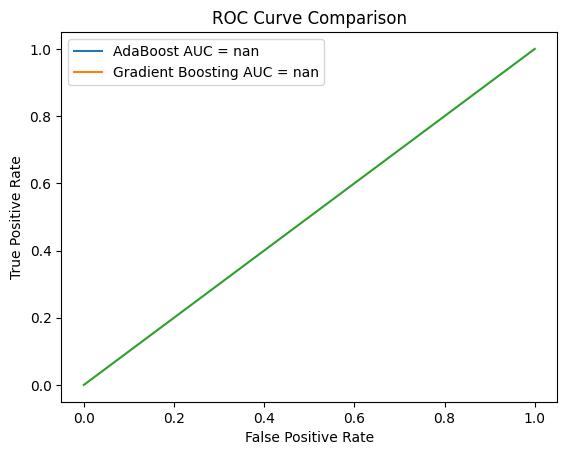

In [19]:
#ROC Curve
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

auc_ada = auc(fpr_ada, tpr_ada)
auc_gb = auc(fpr_gb, tpr_gb)

plt.figure()
plt.plot(fpr_ada, tpr_ada, label="AdaBoost AUC = %.2f" % auc_ada)
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting AUC = %.2f" % auc_gb)

plt.plot([0,1], [0,1])  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

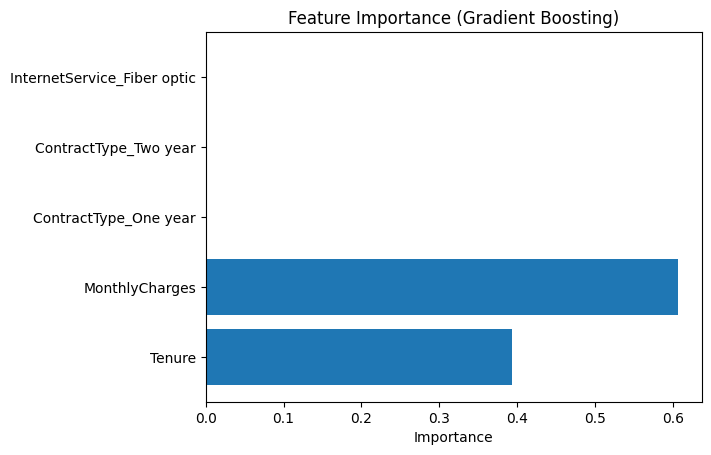

In [20]:
#Feature Importance Plot
# Gradient Boosting Feature Importance
importance = gb_model.feature_importances_

feature_names = X.columns

plt.figure()
plt.barh(feature_names, importance)
plt.xlabel("Importance")
plt.title("Feature Importance (Gradient Boosting)")
plt.show()

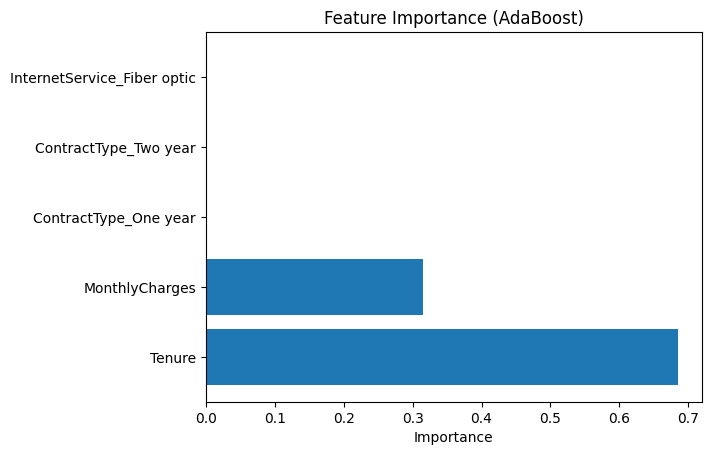

In [21]:
# AdaBoost Feature Importance
importance_ada = ada_model.feature_importances_

feature_names = X.columns

plt.figure()
plt.barh(feature_names, importance_ada)
plt.xlabel("Importance")
plt.title("Feature Importance (AdaBoost)")
plt.show()

**SCENARIO 3 – Random Forest**

Problem Statement:
Predict whether a person earns >50K salary.
Dataset:
Adult Income Dataset
Target Variable:
Income (>50K or <=50K)
Input Features:
Age, Education, Occupation, Hours-per-week

IN-LAB TASKS
•	Train Random Forest
•	Tune number of trees
•	Evaluate model
Visualization
•	Feature Importance
•	Accuracy vs Number of Trees graph


In [22]:
#Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

In [23]:
#Load Dataset
data = pd.read_csv("income_random_forest.csv")


In [24]:
data.head()

,Age,EducationYears,HoursPerWeek,Experience,Income
0,37,12,44,12,0
1,46,19,58,33,1
2,53,10,54,24,0
3,46,11,22,6,0
4,36,17,56,3,1


In [25]:
#Preprocessing
# Convert target variable (>50K / <=50K → 1/0)
le = LabelEncoder()
data['Income'] = le.fit_transform(data['Income'])

# Convert categorical features
data = pd.get_dummies(data, drop_first=True)

# Split features and target
X = data.drop("Income", axis=1)
y = data["Income"]

In [26]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [27]:
#Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [28]:
#Tune Number of Trees
trees = [10, 50, 100, 150, 200]
accuracies = []

for n in trees:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)

print(accuracies)

[1.0, 1.0, 1.0, 1.0, 1.0]


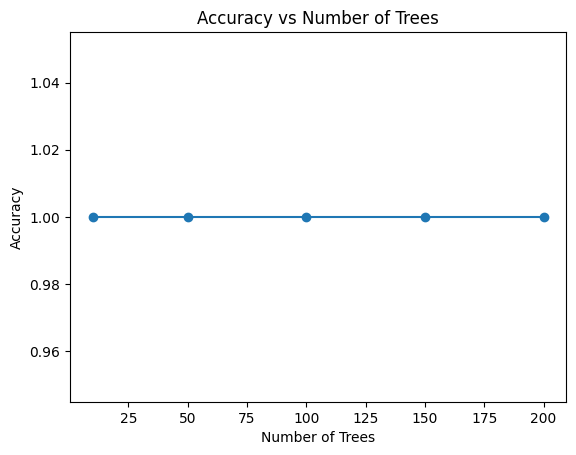

In [29]:
#Accuracy vs Number of Trees Graph
plt.figure()
plt.plot(trees, accuracies, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Trees")
plt.show()

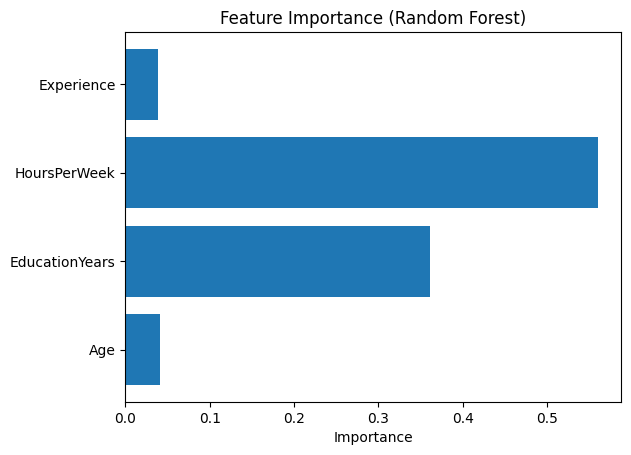

In [31]:
#Feature Importance
importance = rf_model.feature_importances_
feature_names = X.columns

plt.figure()
plt.barh(feature_names, importance)
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()

**SCENARIO 4 – Stacking**

Problem Statement:
Predict heart disease presence.
Dataset:
Heart Disease Dataset
Target Variable:
Presence of Heart Disease (0/1)
Input Features:
Cholesterol, Max Heart Rate, Age

IN-LAB TASKS
•	Train base models (Logistic Regression, SVM, Decision Tree)
•	Combine using StackingClassifier
•	Compare with individual models
Visualization
•	Model comparison bar chart


In [32]:
#Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

In [34]:
#Load Dataset
data = pd.read_csv("heart_stacking.csv")

In [35]:
data.head()

,Age,Cholesterol,MaxHeartRate,RestingBP,HeartDisease
0,57,212,189,118,0
1,44,266,155,146,1
2,59,279,168,128,1
3,66,237,123,145,1
4,58,221,125,132,0


In [36]:
#Preprocessing
# Split features and target
X = data.drop("HeartDisease", axis=1)   # or 'HeartDisease' based on dataset
y = data["HeartDisease"]

# Feature Scaling (important for SVM & Logistic Regression)
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [37]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [38]:
#Train Base Models
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.8333333333333334


In [39]:
#SVM
svm = SVC(probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", acc_svm)

SVM Accuracy: 0.875


In [40]:
#Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.9583333333333334


In [41]:
#Stacking Classifier
estimators = [
    ('lr', LogisticRegression()),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier())
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack_model.fit(X_train, y_train)

y_pred_stack = stack_model.predict(X_test)
acc_stack = accuracy_score(y_test, y_pred_stack)

print("Stacking Accuracy:", acc_stack)

Stacking Accuracy: 0.9583333333333334


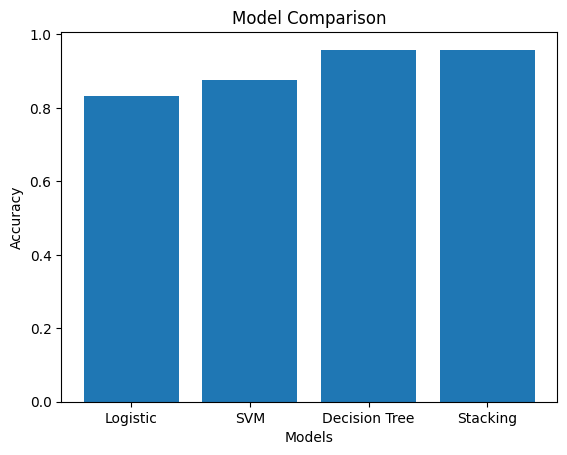

In [42]:
#Model Comparison (Bar Chart)
models = ["Logistic", "SVM", "Decision Tree", "Stacking"]
accuracies = [acc_lr, acc_svm, acc_dt, acc_stack]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

**SCENARIO 5 – SMOTE**

Problem Statement:
Detect fraudulent transactions.
Dataset:
Credit Card Fraud Detection Dataset
Target Variable:
Fraud (0 = Normal, 1 = Fraud)
Input Features:
Transaction Amount, Time, PCA features

IN-LAB TASKS
•	Check class imbalance
•	Apply SMOTE
•	Train model before & after SMOTE
•	Compare performance

Visualization
•	Class distribution (Before & After SMOTE)
•	Precision-Recall Curve


In [43]:
#Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt

In [44]:
#Load Dataset
data = pd.read_csv("fraud_smote.csv")

In [45]:
data.head()

,Amount,Time,Feature1,Feature2,Fraud
0,3233.38,34595,2.157308,-0.818199,0
1,2783.63,73166,1.561511,0.955305,0
2,923.74,84417,-0.027305,-1.418366,0
3,2214.14,11139,-0.643518,-0.466037,0
4,444.75,37847,0.021272,-0.529053,0


In [46]:
#Check Class Imbalance
print(data['Fraud'].value_counts())

Fraud
0    110
1     10
Name: count, dtype: int64


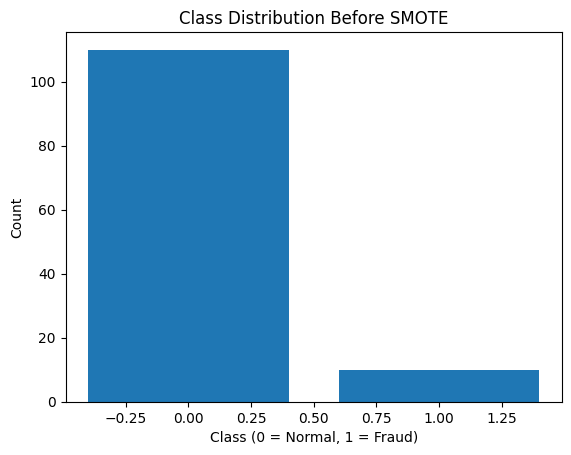

In [47]:
#Visualize Class Distribution (Before SMOTE)
before_counts = data['Fraud'].value_counts()

plt.figure()
plt.bar(before_counts.index, before_counts.values)
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.title("Class Distribution Before SMOTE")
plt.show()

In [48]:
#Split Data
X = data.drop("Fraud", axis=1)
y = data["Fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [49]:
#Train Model BEFORE SMOTE
model_before = RandomForestClassifier(random_state=42)
model_before.fit(X_train, y_train)

y_pred_before = model_before.predict(X_test)

print("Before SMOTE:\n")
print(classification_report(y_test, y_pred_before))

Before SMOTE:

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       0.00      0.00      0.00         2

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [50]:
#Apply SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE class distribution:")
print(pd.Series(y_train_smote).value_counts())

After SMOTE class distribution:
Fraud
0    88
1    88
Name: count, dtype: int64


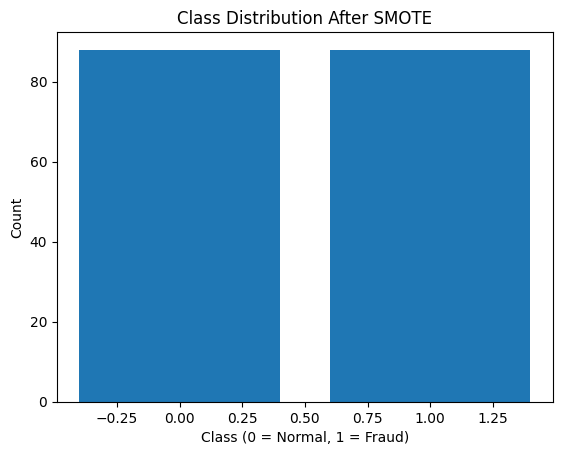

In [51]:
#Visualize After SMOTE
after_counts = pd.Series(y_train_smote).value_counts()

plt.figure()
plt.bar(after_counts.index, after_counts.values)
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.title("Class Distribution After SMOTE")
plt.show()

In [52]:
#Train Model AFTER SMOTE
model_after = RandomForestClassifier(random_state=42)
model_after.fit(X_train_smote, y_train_smote)

y_pred_after = model_after.predict(X_test)

print("After SMOTE:\n")
print(classification_report(y_test, y_pred_after))

After SMOTE:

              precision    recall  f1-score   support

           0       1.00      0.82      0.90        22
           1       0.33      1.00      0.50         2

    accuracy                           0.83        24
   macro avg       0.67      0.91      0.70        24
weighted avg       0.94      0.83      0.87        24



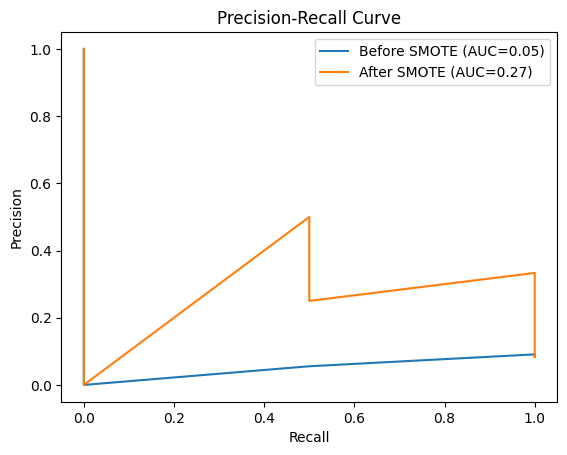

In [53]:
#Precision-Recall Curve
# Probabilities
y_prob_before = model_before.predict_proba(X_test)[:,1]
y_prob_after = model_after.predict_proba(X_test)[:,1]

# PR Curve
precision_b, recall_b, _ = precision_recall_curve(y_test, y_prob_before)
precision_a, recall_a, _ = precision_recall_curve(y_test, y_prob_after)

# AUC
auc_b = auc(recall_b, precision_b)
auc_a = auc(recall_a, precision_a)

plt.figure()
plt.plot(recall_b, precision_b, label="Before SMOTE (AUC=%.2f)" % auc_b)
plt.plot(recall_a, precision_a, label="After SMOTE (AUC=%.2f)" % auc_a)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()